<div style="display: flex; align-items: center; justify-content: flex-start; text-align: left;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Logo_universidad_icesi.svg/960px-Logo_universidad_icesi.svg.png" width="300" style="margin-right: 20px;">
    <div>
        <h3 style="margin: 0;">FACULTAD BARBERI DE INGENIERÍA, DISEÑO Y CIENCIAS APLICADAS</h3>
        <h3 style="margin: 0;">ALGORITMOS Y PROGRAMACIÓN III</h3>
    </div>
</div>

# Proyecto Final

Integrantes:
- ANGY MARIA HURTADO OSORIO A00401755
- HIDEKI TAMURA HERNANDEZ A00348618
- DAVID VERGARA LAVERDE A00402237


## Modelado - Experimentos de Deep Learning (CNN)

Este notebook se enfoca en la construcción de una Red Neuronal Convolucional (CNN) personalizada utilizando **TensorFlow/Keras**. El objetivo es crear un modelo de múltiples salidas (multi-output) que reciba la imagen original y prediga simultáneamente la **Calidad** y el **Tamaño**.

In [23]:
import sys
import os
import pandas as pd
import cv2
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow y Keras para Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Añadir la carpeta raíz al path para importar src
sys.path.append(os.path.abspath('..'))
from src.evaluation.evaluate import evaluate_multioutput_model
from tensorflow.keras.layers import BatchNormalization


In [24]:
gpus = tf.config.list_physical_devices('GPU')
print("GPUs disponibles:", gpus)
# Debe imprimir algo como:
# GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Evitar que TensorFlow acapare toda la VRAM de una vez
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("Memory growth activado ✅")
else:
    print("⚠️ No se detectó GPU, se usará CPU")

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth activado ✅


### 1. Carga de Datos y Preprocesamiento de Imágenes

Para Deep Learning se cargan las imágenes desde `data/processed/metadata.csv` usando `tf.data`. El split se hace con imágenes originales para evitar fuga de datos: el conjunto de test contiene solo originales, mientras que el entrenamiento usa originales de train más imágenes aumentadas.

Además, se aplica la misma normalización z-score de ImageNet usada en `preprocess.py` y `helpers.py`, para que entrenamiento e inferencia usen el mismo pipeline.

In [25]:
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BASE_PATH  = '../data/processed/'

# Normalización z-score de ImageNet.
# Debe coincidir con src/data_processing/preprocess.py y src/utils/helpers.py.
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

metadata = pd.read_csv('../data/processed/metadata.csv')

size_map = {'small': 0, 'medium': 1, 'large': 2}
metadata['size_label'] = metadata['size_category'].map(size_map)

metadata_original  = metadata[metadata['augmented'] == 0].copy().reset_index(drop=True)
metadata_augmented = metadata[metadata['augmented'] == 1].copy().reset_index(drop=True)

# Split limpio: test SOLO con imágenes originales.
# Las aumentadas se agregan únicamente al entrenamiento para evitar fuga de datos.
meta_train_orig, meta_temp = train_test_split(
    metadata_original, test_size=0.3, random_state=42,
    stratify=metadata_original['label']
)
meta_val, meta_test = train_test_split(
    meta_temp, test_size=0.5, random_state=42,
    stratify=meta_temp['label']
)
meta_train = pd.concat([meta_train_orig, metadata_augmented]).reset_index(drop=True)

print(f"Distribución calidad train:\n{meta_train['quality'].value_counts()}")
print(f"Distribución calidad test:\n{meta_test['quality'].value_counts()}")

# Pesos para balancear clases. Se usarán como sample_weight en el Dataset,
# que es más estable que class_weight cuando el modelo tiene múltiples salidas.
clases_q = np.unique(meta_train['label'].values)
pesos_q = compute_class_weight(
    class_weight='balanced',
    classes=clases_q,
    y=meta_train['label'].values
)
class_weights_quality = dict(zip(clases_q.tolist(), pesos_q.astype(np.float32).tolist()))

clases_s = np.unique(meta_train['size_label'].values)
pesos_s = compute_class_weight(
    class_weight='balanced',
    classes=clases_s,
    y=meta_train['size_label'].values
)
class_weights_size = dict(zip(clases_s.tolist(), pesos_s.astype(np.float32).tolist()))

print(f"Pesos calidad: {class_weights_quality}")
print(f"Pesos tamaño:  {class_weights_size}")

def make_dataset(df, batch_size=64, shuffle=True):
    paths    = (BASE_PATH + df['file']).values
    labels_q = df['label'].values.astype('int32')
    labels_s = df['size_label'].values.astype('int32')

    weights_q = compute_class_weight('balanced',
                                      classes=np.unique(labels_q),
                                      y=labels_q)
    sample_weights = np.array([weights_q[l] for l in labels_q], dtype='float32')

    def load_image(path, lq, ls, sw):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
        img = tf.cast(img, tf.float32)
        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        return img, {'quality_output': lq, 'size_output': ls}, sw

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels_q, labels_s, sample_weights)
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=42)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

BATCH_SIZE = 64

train_ds = make_dataset(meta_train, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(meta_val,   batch_size=BATCH_SIZE, shuffle=False)
test_ds  = make_dataset(meta_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nBatches en train: {len(train_ds)}")
print(f"Batches en test:  {len(test_ds)}")


Distribución calidad train:
quality
Good       68615
Bad        42967
Regular    21874
Name: count, dtype: int64
Distribución calidad test:
quality
Good       2190
Bad        1372
Regular     698
Name: count, dtype: int64
Pesos calidad: {0: 1.035337209701538, 1: 0.6483324766159058, 2: 2.033708095550537}
Pesos tamaño:  {0: 4.7440900802612305, 1: 0.9493445158004761, 2: 0.57608562707901}

Batches en train: 2086
Batches en test:  67


### 2. Definición de la Arquitectura CNN Bifurcada (Multi-Output)

Diseñamos una red con un **tronco común** (Common Feature Extractor) compuesto por capas convolucionales para aprender patrones visuales generales (bordes, colores, texturas). Luego, la red se divide en **dos ramas (cabezas)**: una para predecir la calidad y otra para el tamaño.

In [26]:
def build_multioutput_cnn(input_shape=(224, 224, 3), num_quality_classes=3, num_size_classes=3):
    # --- Tronco Común (Feature Extractor) ---
    inputs = Input(shape=input_shape, name='imagen_entrada')
    
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    
    # Usamos GlobalAveragePooling en lugar de Flatten para reducir parámetros y mitigar overfitting
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x) # Regularización
    
    # --- Rama 1: Predicción de Calidad ---
    quality_branch = Dense(64, activation='relu')(x)
    quality_branch = BatchNormalization()(quality_branch)
    quality_branch = Dropout(0.4)(quality_branch)
    quality_output = Dense(num_quality_classes, activation='softmax', name='quality_output')(quality_branch)
    
    # --- Rama 2: Predicción de Tamaño ---
    size_branch = Dense(64, activation='relu')(x)
    size_branch = BatchNormalization()(size_branch)
    size_branch = Dropout(0.4)(size_branch)
    size_output = Dense(num_size_classes, activation='softmax', name='size_output')(size_branch)
    
    # --- Ensamblaje del Modelo ---
    model = Model(
        inputs=inputs,
        outputs={
            'quality_output': quality_output,
            'size_output': size_output
        },
        name='MultiOutput_CNN'
    )
    return model

cnn_model = build_multioutput_cnn()
cnn_model.summary()

Model: "MultiOutput_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ imagen_entrada      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 224, 224,  │        896 │ imagen_entrada[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_8[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 111,558 (435.77 KB)

 Trainable params: 110,854 (433.02 KB)

 Non-trainable params: 704 (2.75 KB)

### 3. Compilación del Modelo

Configuramos la función de pérdida (`loss`) para ambas salidas y asignamos pesos a cada pérdida si fuera necesario. En este caso daremos el mismo peso (1.0) a ambas tareas.

In [27]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        'quality_output': 'sparse_categorical_crossentropy',
        'size_output': 'sparse_categorical_crossentropy'
    },
    metrics={
        'quality_output': ['accuracy'],
        'size_output': ['accuracy']
    }
)

### 4. Entrenamiento con Callbacks, pesos y regularización

Entrenamos con `EarlyStopping`, reducción de tasa de aprendizaje y checkpoint del mejor modelo. El desbalance se corrige con `sample_weight` por salida (`quality_output` y `size_output`) dentro del `tf.data.Dataset`, lo cual es más estable para modelos multi-salida.

In [ ]:
model_dir = '../saved_models'
os.makedirs(model_dir, exist_ok=True)

callbacks = [
    EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor='val_loss'
    ),
    ReduceLROnPlateau(
        factor=0.5,
        patience=3,
        monitor='val_loss'
    ),
    ModelCheckpoint(
        filepath=os.path.join(model_dir, 'cnn_best_checkpoint.keras'),
        save_best_only=True,
        monitor='val_loss'
    )
]

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/60


I0000 00:00:1780779232.715759    7113 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_942798__.83


2085/2086 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 2.0271 - quality_output_accuracy: 0.4840 - quality_output_loss: 1.1770 - size_output_accuracy: 0.6612 - size_output_loss: 0.8501

I0000 00:00:1780779428.946032    7119 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_942798__.83


2086/2086 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 2.0272 - quality_output_accuracy: 0.4840 - quality_output_loss: 1.1771 - size_output_accuracy: 0.6613 - size_output_loss: 0.8501

I0000 00:00:1780779431.443817    7116 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_957968__.26
I0000 00:00:1780779433.287684    7113 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_957968__.26


2086/2086 ━━━━━━━━━━━━━━━━━━━━ 203s 95ms/step - loss: 2.1419 - quality_output_accuracy: 0.4232 - quality_output_loss: 1.3414 - size_output_accuracy: 0.6923 - size_output_loss: 0.8018 - val_loss: 1.8573 - val_quality_output_accuracy: 0.5034 - val_quality_output_loss: 1.0777 - val_size_output_accuracy: 0.6116 - val_size_output_loss: 0.7799 - learning_rate: 1.0000e-04
Epoch 2/60
1189/2086 ━━━━━━━━━━━━━━━━━━━━ 1:23 93ms/step - loss: 1.6602 - quality_output_accuracy: 0.4862 - quality_output_loss: 1.0694 - size_output_accuracy: 0.7594 - size_output_loss: 0.5908

### 5. Curvas de Aprendizaje

Es crucial graficar la pérdida global (loss) para detectar visualmente el sobreajuste.

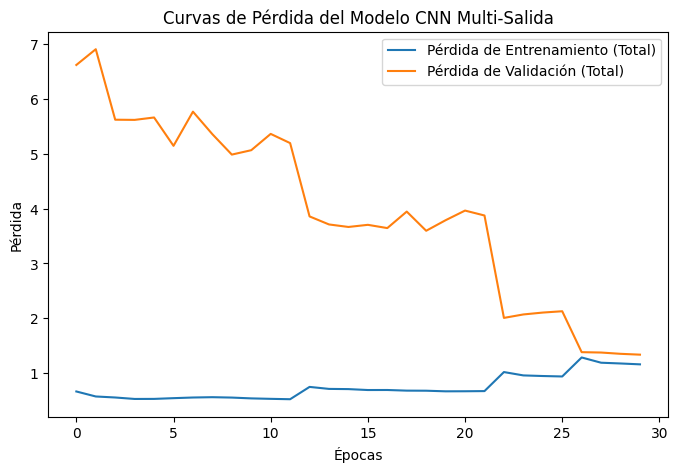

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento (Total)')
plt.plot(history.history['val_loss'], label='Pérdida de Validación (Total)')
plt.title('Curvas de Pérdida del Modelo CNN Multi-Salida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

### 6. Evaluación del Modelo

Realizamos las predicciones sobre el conjunto de test. Keras nos devolverá una lista con dos arrays de probabilidades (uno para calidad y otro para tamaño). Tomaremos el `argmax` para obtener la clase y lo pasaremos a nuestra función centralizada.

I0000 00:00:1780777903.737606    7113 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_930384__.12
I0000 00:00:1780777909.161261    7113 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_937083__.12


Orden de clases calidad: ['Mala', 'Buena', 'Regular']
Orden de clases tamaño: ['Pequeño', 'Mediano', 'Grande']
REPORTE DE CLASIFICACIÓN: CALIDAD
              precision    recall  f1-score   support

        Mala       1.00      0.00      0.00      1372
       Buena       0.54      0.99      0.70      2190
     Regular       0.88      0.29      0.44       698

    accuracy                           0.56      4260
   macro avg       0.81      0.43      0.38      4260
weighted avg       0.74      0.56      0.43      4260

REPORTE DE CLASIFICACIÓN: TAMAÑO
              precision    recall  f1-score   support

     Pequeño       0.98      0.68      0.80       402
     Mediano       0.78      0.98      0.87      1588
      Grande       0.99      0.86      0.92      2270

    accuracy                           0.89      4260
   macro avg       0.91      0.84      0.86      4260
weighted avg       0.91      0.89      0.89      4260



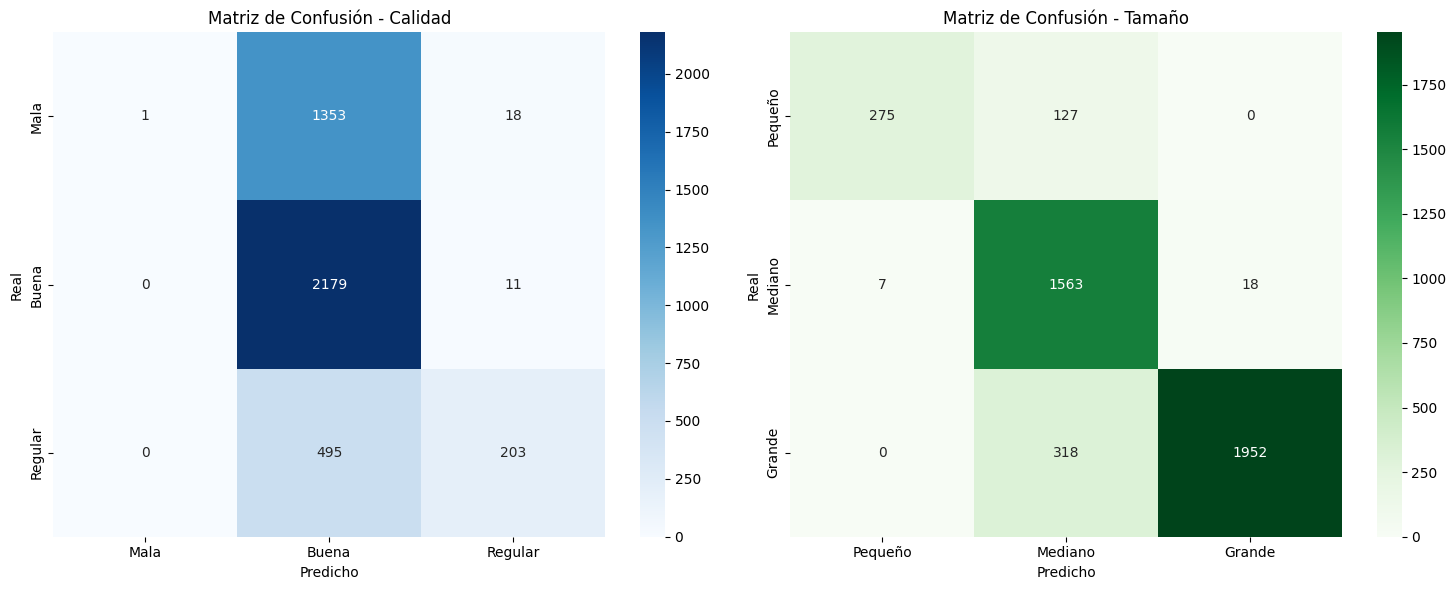

In [21]:
y_test_qual, y_test_size = [], []
y_pred_quality, y_pred_size = [], []

for X_batch, y_batch, _ in test_ds:
    preds = cnn_model.predict(X_batch, verbose=0)

    # Si el modelo fue creado con salidas tipo dict, predict devuelve un dict.
    # Si alguna versión de Keras devuelve lista, se mantiene compatibilidad.
    if isinstance(preds, dict):
        pred_quality_batch = preds['quality_output']
        pred_size_batch = preds['size_output']
    else:
        pred_quality_batch = preds[0]
        pred_size_batch = preds[1]

    y_pred_quality.extend(np.argmax(pred_quality_batch, axis=1))
    y_pred_size.extend(np.argmax(pred_size_batch, axis=1))

    y_test_qual.extend(y_batch['quality_output'].numpy())
    y_test_size.extend(y_batch['size_output'].numpy())

y_test_qual    = np.array(y_test_qual)
y_test_size    = np.array(y_test_size)
y_pred_quality = np.array(y_pred_quality)
y_pred_size    = np.array(y_pred_size)

def _pretty_quality_name(value):
    text = str(value).strip().lower()
    if 'bad' in text or 'mala' in text:
        return 'Mala'
    if 'good' in text or 'buena' in text:
        return 'Buena'
    if 'regular' in text:
        return 'Regular'
    return str(value)

def _pretty_size_name(value):
    text = str(value).strip().lower()
    if text == 'small':
        return 'Pequeño'
    if text == 'medium':
        return 'Mediano'
    if text == 'large':
        return 'Grande'
    return str(value)

# Nombres de clases ordenados según el valor numérico de metadata['label'].
quality_names = (
    metadata_original[['label', 'quality']]
    .drop_duplicates()
    .sort_values('label')['quality']
    .map(_pretty_quality_name)
    .tolist()
)

size_names = (
    metadata_original[['size_label', 'size_category']]
    .drop_duplicates()
    .sort_values('size_label')['size_category']
    .map(_pretty_size_name)
    .tolist()
)

print("Orden de clases calidad:", quality_names)
print("Orden de clases tamaño:", size_names)

# Evaluación usando src/evaluation/evaluate.py
evaluate_multioutput_model(
    y_test_qual,
    y_pred_quality,
    y_test_size,
    y_pred_size,
    quality_classes=quality_names,
    size_classes=size_names
)


### 7. Guardar el Modelo Entrenado

Guardamos el modelo en formato `.keras` dentro de `saved_models/`, que es la carpeta definida por la estructura del proyecto para modelos exportados.

In [22]:
# Guardar en la carpeta definida por la estructura del proyecto
model_dir = '../saved_models'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'cnn_multioutput.keras')
cnn_model.save(model_path)

print(f"Modelo de Deep Learning guardado exitosamente en: {model_path}")


Modelo de Deep Learning guardado exitosamente en: ../saved_models/cnn_multioutput.keras
